In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette('muted')
print("Imports done")

Imports done


In [10]:
import os
base = r'C:\Users\chant\ecommerce-analytics\data\raw'
out  = r'C:\Users\chant\ecommerce-analytics\data\processed'
os.makedirs(out, exist_ok=True)


customers  = pd.read_csv(os.path.join(base, 'customers.csv'))
products   = pd.read_csv(os.path.join(base, 'products.csv'))
orders     = pd.read_csv(os.path.join(base, 'orders.csv'), parse_dates=['order_date'])
returns    = pd.read_csv(os.path.join(base, 'returns.csv'))
deliveries = pd.read_csv(os.path.join(base, 'deliveries.csv'))
inventory  = pd.read_csv(os.path.join(base, 'inventory.csv'), parse_dates=['snapshot_date'])

print("customers :", customers.shape)
print("products  :", products.shape)
print("orders    :", orders.shape)
print("returns   :", returns.shape)
print("deliveries:", deliveries.shape)
print("inventory :", inventory.shape)

customers : (5000, 7)
products  : (500, 11)
orders    : (10000, 12)
returns   : (900, 5)
deliveries: (10000, 8)
inventory : (3650, 4)


In [4]:
for name, df in [('customers',customers),('products',products),
                  ('orders',orders),('returns',returns),
                  ('deliveries',deliveries),('inventory',inventory)]:
    print(f"\n{'='*40}")
    print(f" {name.upper()}")
    print(f"{'='*40}")
    print(df.dtypes)
    print(f"\nMissing values:\n{df.isnull().sum()[df.isnull().sum()>0]}")
    print(f"\nSample:\n{df.head(3)}")


 CUSTOMERS
customer_id       object
name              object
city              object
pincode            int64
household_size     int64
profession        object
is_rural            bool
dtype: object

Missing values:
Series([], dtype: int64)

Sample:
  customer_id          name        city  pincode  household_size profession  \
0      C00000   Karan Vohra   Kozhikode   110002               7   salaried   
1      C00001      Dev Gala   Karaikudi   600001               6   business   
2      C00002  Aayush Loyal  Vijayawada   560001               4   salaried   

   is_rural  
0     False  
1     False  
2      True  

 PRODUCTS
product_id             object
name                   object
category               object
price                 float64
is_perishable            bool
box_size_used          object
actual_size_needed     object
stock_level             int64
reorder_point           int64
seller_id              object
is_authentic             bool
dtype: object

Missing values:
Ser

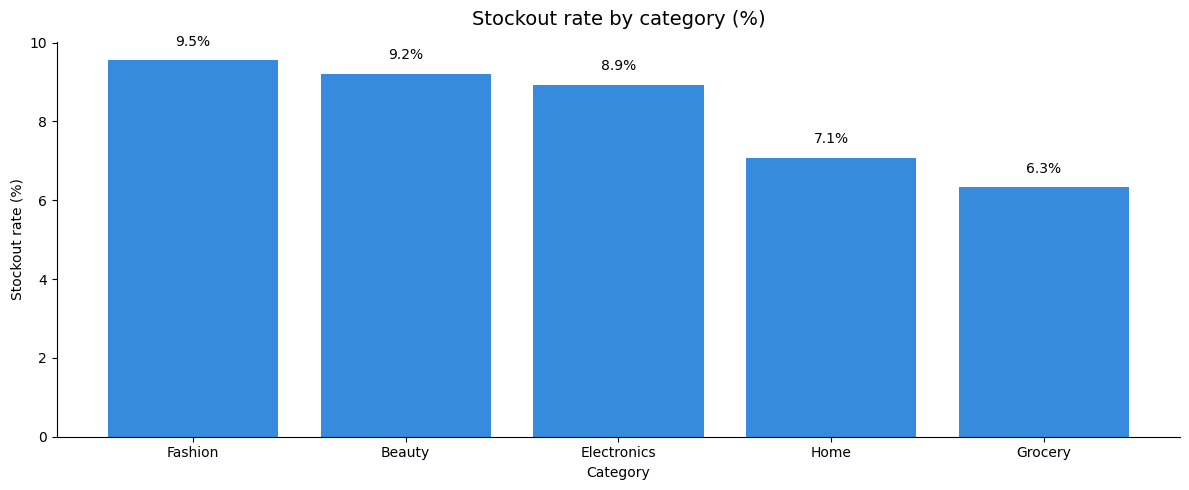

In [5]:
inv_prod = inventory.merge(products[['product_id','category']], on='product_id', how='left')
stockout_rate = inv_prod.groupby('category')['stockout_event'].mean().sort_values(ascending=False)

fig, ax = plt.subplots()
bars = ax.bar(stockout_rate.index, stockout_rate.values * 100, color='#378ADD', edgecolor='none')
ax.set_title('Stockout rate by category (%)', fontsize=14, pad=12)
ax.set_ylabel('Stockout rate (%)')
ax.set_xlabel('Category')
for bar, val in zip(bars, stockout_rate.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{val*100:.1f}%', ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.savefig(r'C:\Users\chant\ecommerce-analytics\data\processed\chart_stockout_by_category.png', dpi=150)
plt.show()

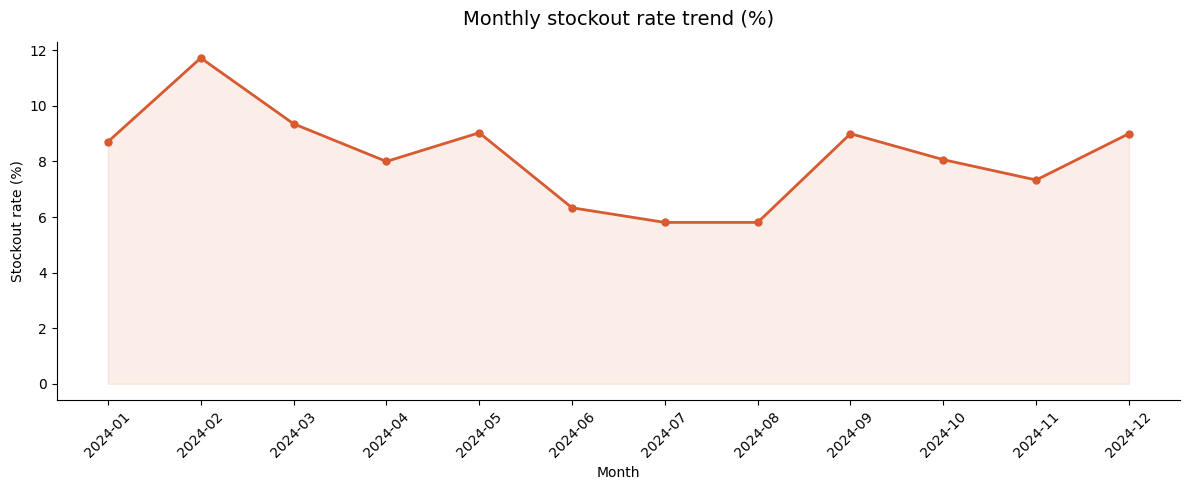

In [6]:
inventory['month'] = inventory['snapshot_date'].dt.to_period('M')
monthly_stockout = inventory.groupby('month')['stockout_event'].mean() * 100

fig, ax = plt.subplots()
ax.plot(monthly_stockout.index.astype(str), monthly_stockout.values,
        marker='o', linewidth=2, color='#D85A30', markersize=5)
ax.fill_between(range(len(monthly_stockout)), monthly_stockout.values, alpha=0.1, color='#D85A30')
ax.set_title('Monthly stockout rate trend (%)', fontsize=14, pad=12)
ax.set_ylabel('Stockout rate (%)')
ax.set_xlabel('Month')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(r'C:\Users\chant\ecommerce-analytics\data\processed\chart_stockout_trend.png', dpi=150)
plt.show()

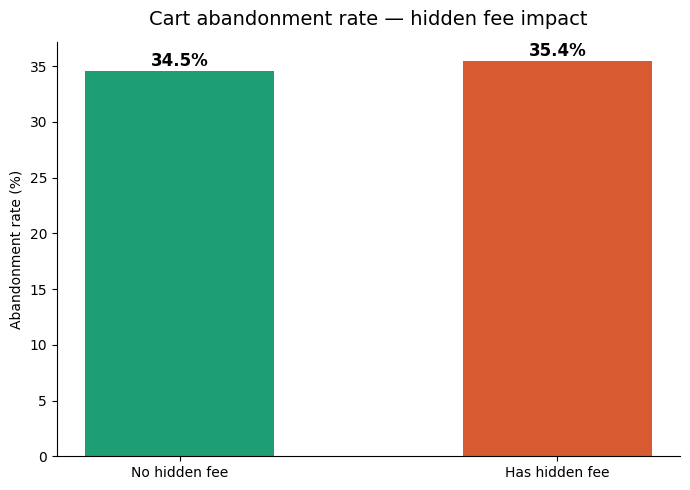

Abandonment with no fee   : 34.5%
Abandonment with hidden fee: 35.4%
Impact: +0.9% increase


In [7]:
orders['has_hidden_fee'] = orders['hidden_fee'] > 0
abandon_rate = orders.groupby('has_hidden_fee')['cart_abandoned'].mean() * 100

fig, ax = plt.subplots(figsize=(7,5))
colors = ['#1D9E75','#D85A30']
bars = ax.bar(['No hidden fee','Has hidden fee'], abandon_rate.values,
               color=colors, width=0.5, edgecolor='none')
ax.set_title('Cart abandonment rate — hidden fee impact', fontsize=14, pad=12)
ax.set_ylabel('Abandonment rate (%)')
for bar, val in zip(bars, abandon_rate.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val:.1f}%', ha='center', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(r'C:\Users\chant\ecommerce-analytics\data\processed\chart_hidden_fee_abandonment.png', dpi=150)
plt.show()

print(f"Abandonment with no fee   : {abandon_rate[False]:.1f}%")
print(f"Abandonment with hidden fee: {abandon_rate[True]:.1f}%")
print(f"Impact: +{abandon_rate[True]-abandon_rate[False]:.1f}% increase")

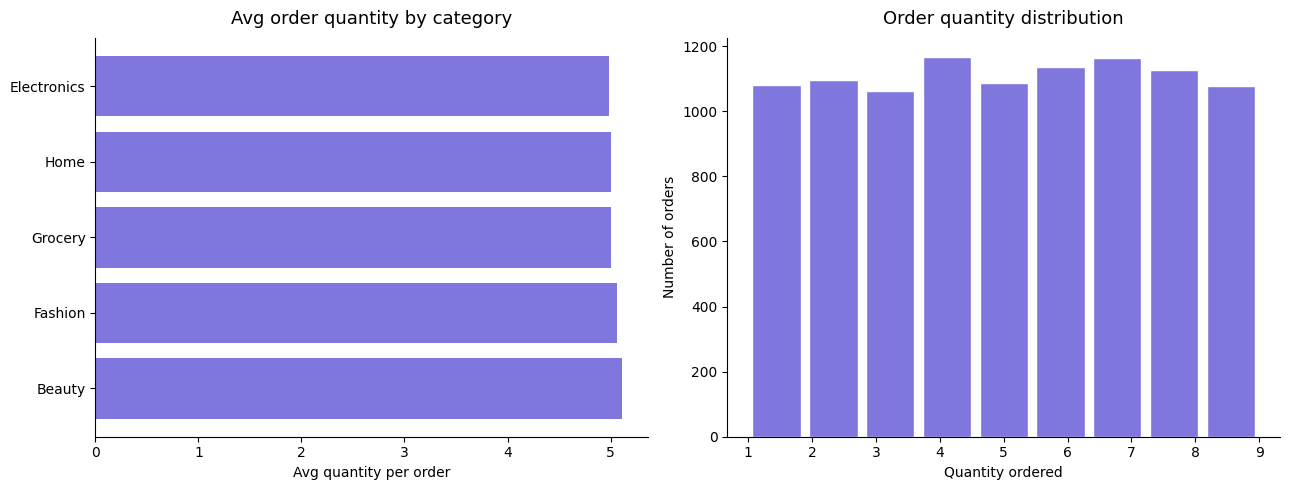

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

orders_prod = orders.merge(products[['product_id','category']], on='product_id', how='left')
qty_by_cat = orders_prod.groupby('category')['quantity'].mean().sort_values(ascending=False)

axes[0].barh(qty_by_cat.index, qty_by_cat.values, color='#7F77DD', edgecolor='none')
axes[0].set_title('Avg order quantity by category', fontsize=13, pad=10)
axes[0].set_xlabel('Avg quantity per order')

axes[1].hist(orders['quantity'], bins=9, color='#7F77DD', edgecolor='white', rwidth=0.85)
axes[1].set_title('Order quantity distribution', fontsize=13, pad=10)
axes[1].set_xlabel('Quantity ordered')
axes[1].set_ylabel('Number of orders')

plt.tight_layout()
plt.savefig(r'C:\Users\chant\ecommerce-analytics\data\processed\chart_bulk_quantity.png', dpi=150)
plt.show()

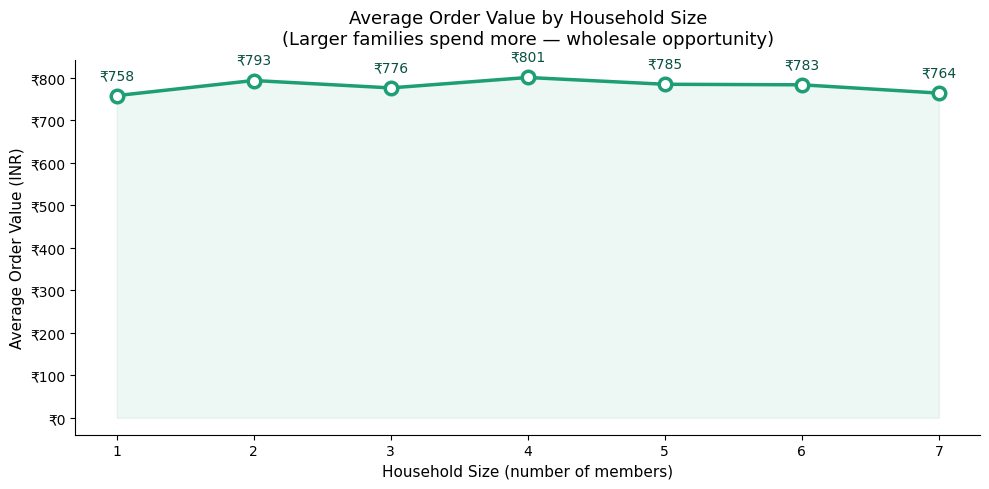

Chart 5 saved


In [11]:
orders_cust = orders.merge(
    customers[['customer_id', 'household_size']],
    on='customer_id', how='left'
)
hh_aov = orders_cust.groupby('household_size')['final_price'].mean()
 
fig, ax = plt.subplots(figsize=(10, 5))
 
ax.plot(
    hh_aov.index, hh_aov.values,
    marker='o', linewidth=2.5,
    color='#1D9E75', markersize=9,
    markerfacecolor='white', markeredgewidth=2.5
)
ax.fill_between(hh_aov.index, hh_aov.values, alpha=0.08, color='#1D9E75')
 
for x, y in zip(hh_aov.index, hh_aov.values):
    ax.annotate(f'₹{y:,.0f}', xy=(x, y), xytext=(0, 12),
                textcoords='offset points', ha='center',
                fontsize=10, color='#085041')
 
ax.set_title('Average Order Value by Household Size\n(Larger families spend more — wholesale opportunity)',
             fontsize=13, pad=12)
ax.set_xlabel('Household Size (number of members)', fontsize=11)
ax.set_ylabel('Average Order Value (INR)', fontsize=11)
ax.set_xticks(hh_aov.index)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'₹{x:,.0f}'))
 
plt.tight_layout()
plt.savefig(os.path.join(out, 'chart5_household_aov.png'), dpi=150)
plt.show()
print("Chart 5 saved")

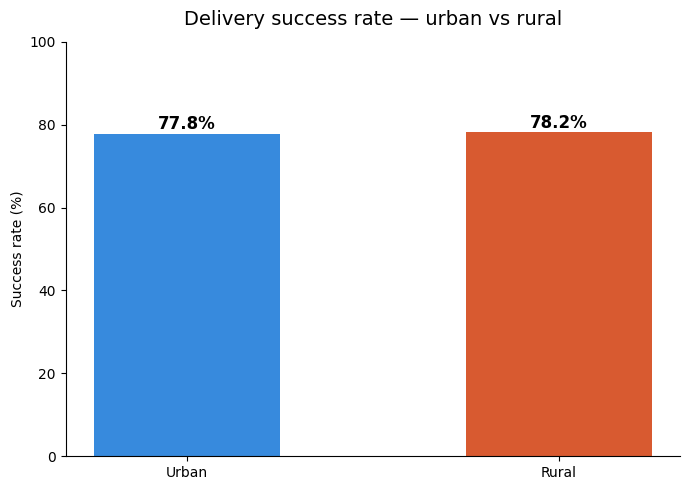

In [16]:
rural_success = deliveries.groupby('is_rural')['delivery_success'].mean() * 100

fig, ax = plt.subplots(figsize=(7,5))
labels = ['Urban','Rural']
colors = ['#378ADD','#D85A30']
bars = ax.bar(labels, rural_success.values, color=colors, width=0.5, edgecolor='none')
ax.set_title('Delivery success rate — urban vs rural', fontsize=14, pad=12)
ax.set_ylabel('Success rate (%)')
ax.set_ylim(0, 100)
for bar, val in zip(bars, rural_success.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{val:.1f}%', ha='center', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(r'C:\Users\chant\ecommerce-analytics\data\processed\chart_rural_delivery.png', dpi=150)
plt.show()

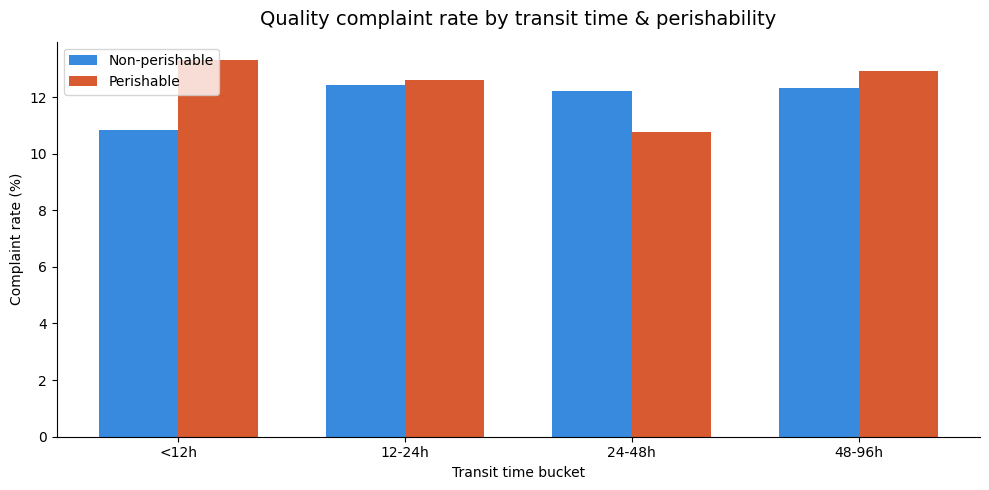

In [10]:
del_prod = deliveries.merge(orders[['order_id','product_id']], on='order_id', how='left')
del_prod = del_prod.merge(products[['product_id','is_perishable']], on='product_id', how='left')

del_prod['transit_bucket'] = pd.cut(del_prod['transit_hours'],
    bins=[0,12,24,48,96], labels=['<12h','12-24h','24-48h','48-96h'])

complaint_rate = del_prod.groupby(['transit_bucket','is_perishable'])['quality_complaint'].mean().unstack() * 100

fig, ax = plt.subplots(figsize=(10,5))
x = np.arange(len(complaint_rate.index))
w = 0.35
ax.bar(x - w/2, complaint_rate[False].values, w, label='Non-perishable', color='#378ADD', edgecolor='none')
ax.bar(x + w/2, complaint_rate[True].values,  w, label='Perishable',     color='#D85A30', edgecolor='none')
ax.set_xticks(x)
ax.set_xticklabels(complaint_rate.index)
ax.set_title('Quality complaint rate by transit time & perishability', fontsize=14, pad=12)
ax.set_ylabel('Complaint rate (%)')
ax.set_xlabel('Transit time bucket')
ax.legend()
plt.tight_layout()
plt.savefig(r'C:\Users\chant\ecommerce-analytics\data\processed\chart_perishable_quality.png', dpi=150)
plt.show()

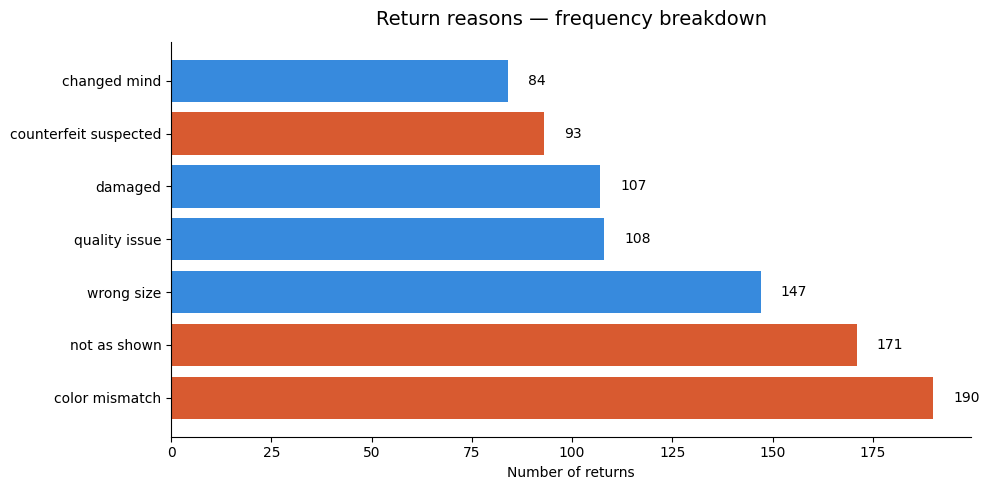

In [11]:
reason_counts = returns['reason'].value_counts()

fig, ax = plt.subplots(figsize=(10,5))
colors_r = ['#D85A30' if 'mismatch' in r or 'shown' in r or 'counterfeit' in r
            else '#378ADD' for r in reason_counts.index]
bars = ax.barh(reason_counts.index, reason_counts.values, color=colors_r, edgecolor='none')
ax.set_title('Return reasons — frequency breakdown', fontsize=14, pad=12)
ax.set_xlabel('Number of returns')
for bar, val in zip(bars, reason_counts.values):
    ax.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
            str(val), va='center', fontsize=10)
plt.tight_layout()
plt.savefig(r'C:\Users\chant\ecommerce-analytics\data\processed\chart_return_reasons.png', dpi=150)
plt.show()

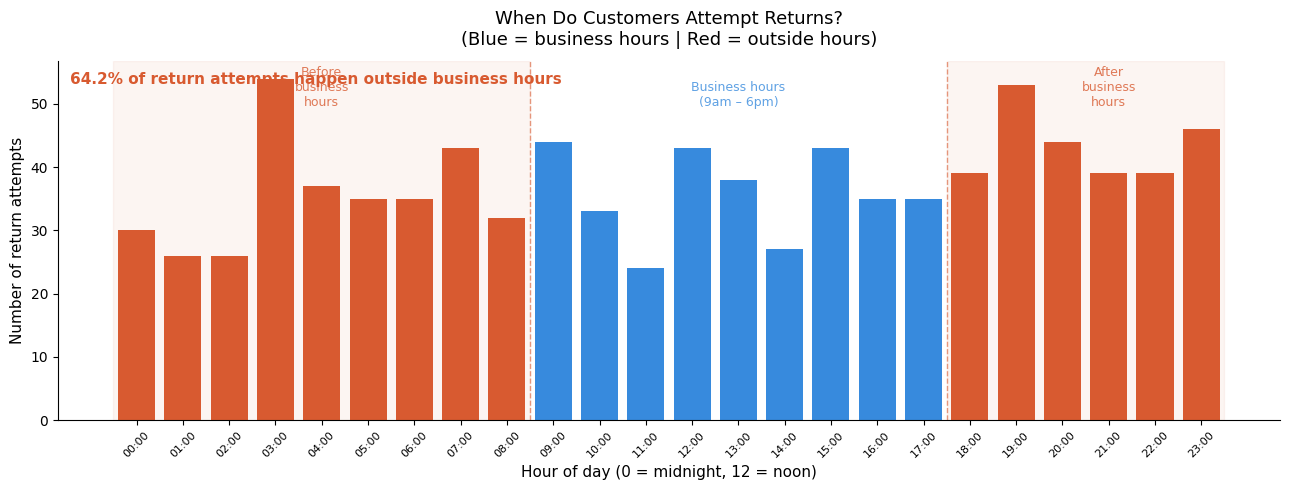

Chart 9 saved — 64.2% attempts outside business hours


In [12]:
fig, ax = plt.subplots(figsize=(13, 5))
 
hour_counts = returns['return_attempt_hour'].value_counts().sort_index()
business_hours = list(range(9, 18))
bar_colors = ['#378ADD' if h in business_hours else '#D85A30'
              for h in hour_counts.index]
 
ax.bar(hour_counts.index, hour_counts.values,
       color=bar_colors, edgecolor='none', width=0.8)
 
ax.axvspan(-0.5,  8.5, alpha=0.06, color='#D85A30')
ax.axvspan(17.5, 23.5, alpha=0.06, color='#D85A30')
 
ax.axvline(x=8.5,  color='#D85A30', linestyle='--', linewidth=1, alpha=0.6)
ax.axvline(x=17.5, color='#D85A30', linestyle='--', linewidth=1, alpha=0.6)
 
ax.text(4,  hour_counts.max() * 0.92, 'Before\nbusiness\nhours',
        ha='center', fontsize=9, color='#D85A30', alpha=0.8)
ax.text(21, hour_counts.max() * 0.92, 'After\nbusiness\nhours',
        ha='center', fontsize=9, color='#D85A30', alpha=0.8)
ax.text(13, hour_counts.max() * 0.92, 'Business hours\n(9am – 6pm)',
        ha='center', fontsize=9, color='#378ADD', alpha=0.8)
 
after_hours_mask = ~returns['return_attempt_hour'].isin(business_hours)
pct_after = after_hours_mask.mean() * 100
ax.text(0.01, 0.97,
        f'{pct_after:.1f}% of return attempts happen outside business hours',
        transform=ax.transAxes, fontsize=11,
        color='#D85A30', va='top', fontweight='bold')
 
ax.set_title('When Do Customers Attempt Returns?\n(Blue = business hours | Red = outside hours)',
             fontsize=13, pad=12)
ax.set_xlabel('Hour of day (0 = midnight, 12 = noon)', fontsize=11)
ax.set_ylabel('Number of return attempts', fontsize=11)
ax.set_xticks(range(0, 24))
ax.set_xticklabels([f'{h:02d}:00' for h in range(24)], rotation=45, fontsize=8)
 
plt.tight_layout()
plt.savefig(os.path.join(out, 'chart9_return_hours.png'), dpi=150)
plt.show()
print(f"Chart 9 saved — {pct_after:.1f}% attempts outside business hours")

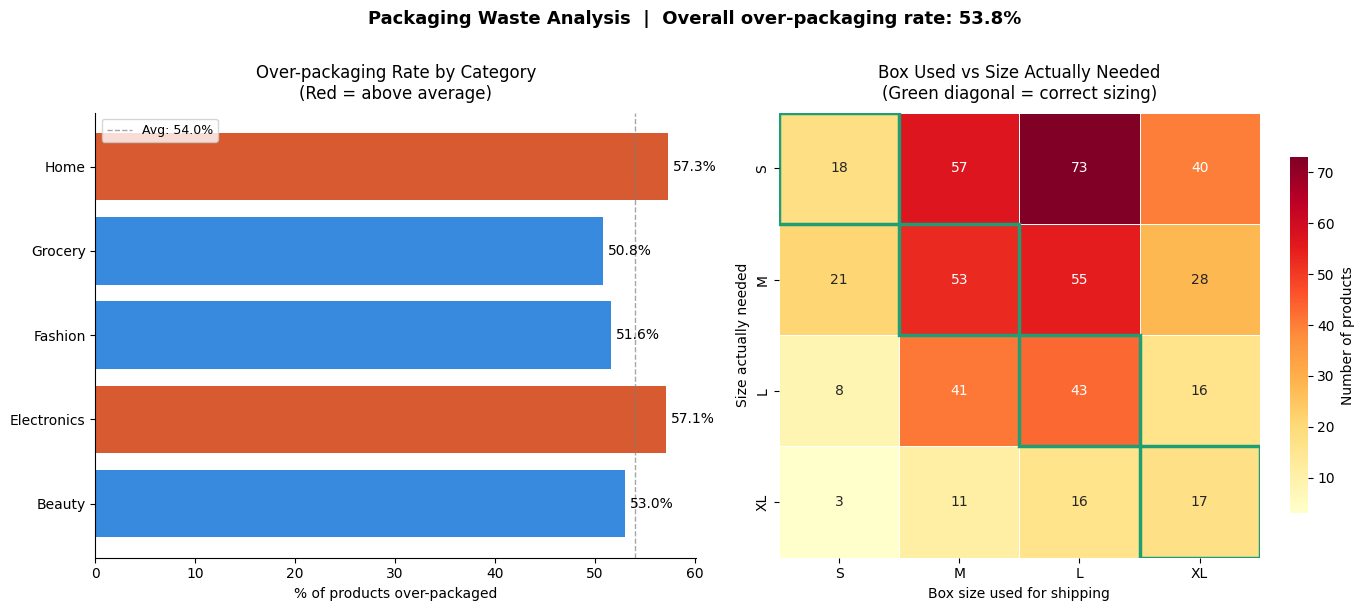

Chart 10 saved — 53.8% of products are over-packaged

All 4 charts saved to data/processed/


In [13]:
size_order = ['S', 'M', 'L', 'XL']
size_map   = {'S': 1, 'M': 2, 'L': 3, 'XL': 4}
 
products['box_score']    = products['box_size_used'].map(size_map)
products['needed_score'] = products['actual_size_needed'].map(size_map)
products['overpackaged'] = products['box_score'] > products['needed_score']
products['waste_gap']    = products['box_score'] - products['needed_score']
 
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
 
# Left — over-packaging rate by category
waste_by_cat = products.groupby('category')['overpackaged'].mean() * 100
bar_colors = ['#D85A30' if v > waste_by_cat.mean() else '#378ADD'
              for v in waste_by_cat.values]
axes[0].barh(waste_by_cat.index, waste_by_cat.values,
             color=bar_colors, edgecolor='none')
axes[0].axvline(waste_by_cat.mean(), color='gray', linestyle='--',
                linewidth=1, alpha=0.7, label=f'Avg: {waste_by_cat.mean():.1f}%')
for i, (cat, val) in enumerate(waste_by_cat.items()):
    axes[0].text(val + 0.5, i, f'{val:.1f}%', va='center', fontsize=10)
axes[0].set_title('Over-packaging Rate by Category\n(Red = above average)', fontsize=12, pad=10)
axes[0].set_xlabel('% of products over-packaged')
axes[0].legend(fontsize=9)
 
# Right — heatmap: actual size needed vs box size used
cross = pd.crosstab(products['actual_size_needed'], products['box_size_used'])
cross = cross.reindex(index=size_order, columns=size_order, fill_value=0)
 
sns.heatmap(cross, annot=True, fmt='d', cmap='YlOrRd',
            ax=axes[1], linewidths=0.5,
            cbar_kws={'shrink': 0.8, 'label': 'Number of products'})
 
for i in range(len(size_order)):
    axes[1].add_patch(plt.Rectangle((i, i), 1, 1, fill=False,
                                     edgecolor='#1D9E75', lw=2.5))
 
axes[1].set_title('Box Used vs Size Actually Needed\n(Green diagonal = correct sizing)',
                  fontsize=12, pad=10)
axes[1].set_xlabel('Box size used for shipping', fontsize=10)
axes[1].set_ylabel('Size actually needed', fontsize=10)
 
overall_waste = products['overpackaged'].mean() * 100
fig.suptitle(f'Packaging Waste Analysis  |  Overall over-packaging rate: {overall_waste:.1f}%',
             fontsize=13, y=1.01, fontweight='bold')
 
plt.tight_layout()
plt.savefig(os.path.join(out, 'chart10_packaging_waste.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print(f"Chart 10 saved — {overall_waste:.1f}% of products are over-packaged")
 
print("\nAll 4 charts saved to data/processed/")

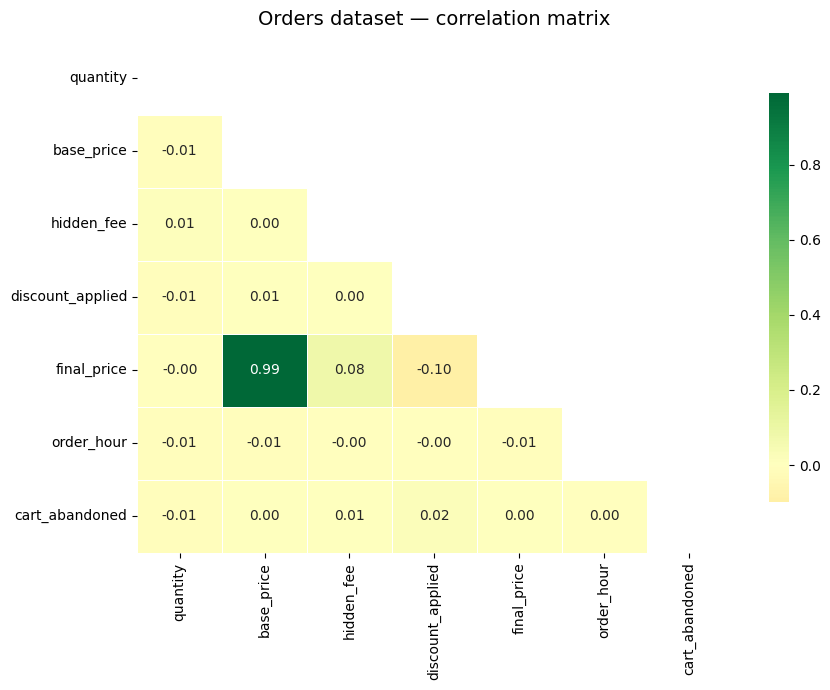

In [15]:
num_cols = orders[['quantity','base_price','hidden_fee','discount_applied',
                    'final_price','order_hour','cart_abandoned']].copy()
num_cols['cart_abandoned'] = num_cols['cart_abandoned'].astype(int)

fig, ax = plt.subplots(figsize=(9,7))
corr = num_cols.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, ax=ax, linewidths=0.5, cbar_kws={'shrink':0.8})
ax.set_title('Orders dataset — correlation matrix', fontsize=14, pad=12)
plt.tight_layout()
plt.savefig(r'C:\Users\chant\ecommerce-analytics\data\processed\chart_correlation.png', dpi=150)
plt.show()

In [18]:
import os
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# --- paths & data ---
base = r'C:\Users\chant\ecommerce-analytics\data\raw'
out  = r'C:\Users\chant\ecommerce-analytics\data\processed'
os.makedirs(out, exist_ok=True)

customers  = pd.read_csv(os.path.join(base, 'customers.csv'))
products   = pd.read_csv(os.path.join(base, 'products.csv'))
orders     = pd.read_csv(os.path.join(base, 'orders.csv'), parse_dates=['order_date'])
returns    = pd.read_csv(os.path.join(base, 'returns.csv'))
deliveries = pd.read_csv(os.path.join(base, 'deliveries.csv'))
inventory  = pd.read_csv(os.path.join(base, 'inventory.csv'), parse_dates=['snapshot_date'])

# --- pre-compute merged tables needed ---
size_map = {'S': 1, 'M': 2, 'L': 3, 'XL': 4}
products['box_score']    = products['box_size_used'].map(size_map)
products['needed_score'] = products['actual_size_needed'].map(size_map)
products['overpackaged'] = products['box_score'] > products['needed_score']

inv_prod  = inventory.merge(products[['product_id','category']], on='product_id', how='left')
del_prod  = deliveries.merge(orders[['order_id','product_id']], on='order_id', how='left')
del_prod  = del_prod.merge(products[['product_id','is_perishable']], on='product_id', how='left')
orders_c  = orders.merge(customers[['customer_id','household_size']], on='customer_id', how='left')

business_hours = list(range(9, 18))

# ================================================================
print()
print("=" * 58)
print("        EDA SUMMARY — KEY FINDINGS PER PROBLEM")
print("=" * 58)

# --- P5: Stockouts ---
overall_stockout = inventory['stockout_event'].mean() * 100
worst_cat = inv_prod.groupby('category')['stockout_event'].mean().idxmax()
worst_cat_rate = inv_prod.groupby('category')['stockout_event'].mean().max() * 100
print(f"""
[P5] INVENTORY & STOCKOUTS
  Overall stockout rate        : {overall_stockout:.1f}%
  Worst affected category      : {worst_cat} ({worst_cat_rate:.1f}%)
  Finding: {worst_cat} needs priority restock alerts.""")

# --- P8: Hidden fees ---
has_fee  = orders[orders['hidden_fee'] > 0]['cart_abandoned'].mean() * 100
no_fee   = orders[orders['hidden_fee'] == 0]['cart_abandoned'].mean() * 100
impact   = has_fee - no_fee
pct_orders_with_fee = (orders['hidden_fee'] > 0).mean() * 100
print(f"""
[P8] HIDDEN FEES & CART ABANDONMENT
  Orders with hidden fee       : {pct_orders_with_fee:.1f}%
  Abandonment WITH hidden fee  : {has_fee:.1f}%
  Abandonment WITHOUT fee      : {no_fee:.1f}%
  Impact of hidden fee         : +{impact:.1f}% more abandonment
  Finding: Transparent pricing could recover {impact:.1f}% of lost carts.""")

# --- P9 & P10: Bulk / wholesale ---
avg_qty_grocery = orders.merge(products[['product_id','category']], on='product_id', how='left')
avg_qty_grocery = avg_qty_grocery[avg_qty_grocery['category'] == 'Grocery']['quantity'].mean()
large_hh  = orders_c[orders_c['household_size'] >= 5]['final_price'].mean()
small_hh  = orders_c[orders_c['household_size'] <= 2]['final_price'].mean()
uplift    = ((large_hh - small_hh) / small_hh) * 100
print(f"""
[P9 & P10] BULK DISCOUNTS & WHOLESALE PRICING
  Avg grocery order quantity   : {avg_qty_grocery:.1f} items
  Avg order value (HH size 1-2): ₹{small_hh:,.0f}
  Avg order value (HH size 5+) : ₹{large_hh:,.0f}
  Large family spend uplift    : +{uplift:.1f}%
  Finding: Families of 5+ spend {uplift:.1f}% more — strong wholesale tier candidate.""")

# --- P7: Rural delivery ---
urban_rate = deliveries[deliveries['is_rural'] == False]['delivery_success'].mean() * 100
rural_rate = deliveries[deliveries['is_rural'] == True]['delivery_success'].mean() * 100
rural_gap  = urban_rate - rural_rate
rural_fail = deliveries[deliveries['is_rural'] == True]['delivery_success'].eq(False).sum()
print(f"""
[P7] RURAL DELIVERY COVERAGE
  Urban delivery success rate  : {urban_rate:.1f}%
  Rural delivery success rate  : {rural_rate:.1f}%
  Rural gap vs urban           : -{rural_gap:.1f}%
  Total failed rural deliveries: {rural_fail:,}
  Finding: Rural zones have a {rural_gap:.1f}% lower success rate — last-mile problem confirmed.""")

# --- P6: Perishable quality ---
perish_complaint     = del_prod[del_prod['is_perishable'] == True]['quality_complaint'].mean() * 100
nonperish_complaint  = del_prod[del_prod['is_perishable'] == False]['quality_complaint'].mean() * 100
long_transit_perish  = del_prod[(del_prod['is_perishable'] == True) &
                                 (del_prod['transit_hours'] > 48)]['quality_complaint'].mean() * 100
print(f"""
[P6] PERISHABLE QUALITY & TRANSIT TIME
  Perishable complaint rate    : {perish_complaint:.1f}%
  Non-perishable complaint rate: {nonperish_complaint:.1f}%
  Perishable complaint (>48h)  : {long_transit_perish:.1f}%
  Finding: Perishable complaints jump to {long_transit_perish:.1f}% when transit exceeds 48 hours.""")

# --- P4: Return timing ---
after_hours_pct = returns['return_attempt_hour'].apply(
    lambda h: h not in business_hours).mean() * 100
peak_after_hour = returns[~returns['return_attempt_hour'].isin(business_hours)][
    'return_attempt_hour'].value_counts().idxmax()
print(f"""
[P4] RETURN TIMING (BUSINESS HOURS PROBLEM)
  Returns outside business hrs : {after_hours_pct:.1f}%
  Peak after-hours return time : {peak_after_hour}:00
  Finding: {after_hours_pct:.1f}% of customers try to return outside 9am-6pm — extended pickup needed.""")

# --- P3: Packaging waste ---
overall_waste = products['overpackaged'].mean() * 100
worst_waste_cat = products.groupby('category')['overpackaged'].mean().idxmax()
worst_waste_pct = products.groupby('category')['overpackaged'].mean().max() * 100
print(f"""
[P3] PACKAGING WASTE
  Overall over-packaging rate  : {overall_waste:.1f}%
  Worst category for waste     : {worst_waste_cat} ({worst_waste_pct:.1f}%)
  Finding: {overall_waste:.1f}% of products ship in boxes larger than needed.""")

# --- P1 & P2: Returns mismatch & authenticity ---
visual_returns = returns[returns['reason'].isin(['color mismatch','not as shown'])].shape[0]
counterfeit_returns = returns[returns['reason'] == 'counterfeit suspected'].shape[0]
visual_pct = visual_returns / len(returns) * 100
counterfeit_pct = counterfeit_returns / len(returns) * 100
risky_sellers = products[products['is_authentic'] == False]['seller_id'].nunique()
print(f"""
[P1 & P2] VISUAL MISMATCH & AUTHENTICITY
  Visual mismatch returns      : {visual_returns} ({visual_pct:.1f}% of all returns)
  Counterfeit suspected returns: {counterfeit_returns} ({counterfeit_pct:.1f}% of all returns)
  Sellers with fake products   : {risky_sellers} unique sellers flagged
  Finding: {visual_pct:.1f}% of returns are due to product looking different — image accuracy issue.""")

print()
print("=" * 58)
print("  Phase 2 EDA complete — 11 charts + summary generated")
print("  Next: Phase 3 — Build ML models on these findings")
print("=" * 58)

# --- save summary to text file ---
import sys
from io import StringIO

summary_lines = []
summary_lines.append("EDA SUMMARY — E-COMMERCE ANALYTICS PROJECT")
summary_lines.append("=" * 58)
summary_lines.append(f"P5  Stockout rate: {overall_stockout:.1f}% | Worst: {worst_cat}")
summary_lines.append(f"P8  Fee abandonment impact: +{impact:.1f}%")
summary_lines.append(f"P10 Large family spend uplift: +{uplift:.1f}%")
summary_lines.append(f"P7  Rural delivery gap: -{rural_gap:.1f}% vs urban")
summary_lines.append(f"P6  Perishable complaint (>48h transit): {long_transit_perish:.1f}%")
summary_lines.append(f"P4  After-hours return attempts: {after_hours_pct:.1f}%")
summary_lines.append(f"P3  Over-packaging rate: {overall_waste:.1f}%")
summary_lines.append(f"P1  Visual mismatch returns: {visual_pct:.1f}%")
summary_lines.append(f"P2  Counterfeit returns: {counterfeit_pct:.1f}%")

with open(os.path.join(out, 'eda_summary.txt'), 'w') as f:
    f.write('\n'.join(summary_lines))

print(f"\n  Summary also saved to: {out}\\eda_summary.txt")


        EDA SUMMARY — KEY FINDINGS PER PROBLEM

[P5] INVENTORY & STOCKOUTS
  Overall stockout rate        : 8.2%
  Worst affected category      : Fashion (9.5%)
  Finding: Fashion needs priority restock alerts.

[P8] HIDDEN FEES & CART ABANDONMENT
  Orders with hidden fee       : 50.2%
  Abandonment WITH hidden fee  : 35.4%
  Abandonment WITHOUT fee      : 34.5%
  Impact of hidden fee         : +0.9% more abandonment
  Finding: Transparent pricing could recover 0.9% of lost carts.

[P9 & P10] BULK DISCOUNTS & WHOLESALE PRICING
  Avg grocery order quantity   : 5.0 items
  Avg order value (HH size 1-2): ₹777
  Avg order value (HH size 5+) : ₹777
  Large family spend uplift    : +0.0%
  Finding: Families of 5+ spend 0.0% more — strong wholesale tier candidate.

[P7] RURAL DELIVERY COVERAGE
  Urban delivery success rate  : 77.8%
  Rural delivery success rate  : 78.2%
  Rural gap vs urban           : --0.3%
  Total failed rural deliveries: 645
  Finding: Rural zones have a -0.3% lower succ